In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from fredapi import Fred
import matplotlib.pyplot as plt

print("hi")

hi


In [2]:
fred = Fred(api_key='dkl ')

In [3]:
macro_data = {
    'CPI'                : fred.get_series('CPIAUCSL'),        # Inflation
    'Unemployment'       : fred.get_series('UNRATE'),          # Labor market
    'Fed_Funds_Rate'     : fred.get_series('FEDFUNDS'),        # Monetary policy
    'Treasury_10Y'       : fred.get_series('GS10'),            # Long-term rates
    'Treasury_2Y'        : fred.get_series('GS2'),             # Short-term rates
    'Industrial_Prod'    : fred.get_series('INDPRO'),          # Manufacturing
    'Consumer_Sentiment' : fred.get_series('UMCSENT'),         # Consumer confidence
}

In [4]:
macro_df = pd.DataFrame(macro_data)
print(macro_df.shape)
print(macro_df.head())

(1286, 7)
            CPI  Unemployment  Fed_Funds_Rate  Treasury_10Y  Treasury_2Y  \
1919-01-01  NaN           NaN             NaN           NaN          NaN   
1919-02-01  NaN           NaN             NaN           NaN          NaN   
1919-03-01  NaN           NaN             NaN           NaN          NaN   
1919-04-01  NaN           NaN             NaN           NaN          NaN   
1919-05-01  NaN           NaN             NaN           NaN          NaN   

            Industrial_Prod  Consumer_Sentiment  
1919-01-01           4.8739                 NaN  
1919-02-01           4.6585                 NaN  
1919-03-01           4.5238                 NaN  
1919-04-01           4.6046                 NaN  
1919-05-01           4.6315                 NaN  


In [5]:
# Trim to 2000 onwards
macro_df = macro_df['2000-01-01':'2024-12-31']

# Resample everything to month start frequency
macro_df = macro_df.resample('MS').first()

# Check how many NaNs we have per column
print("Shape:", macro_df.shape)
print("\nNull counts:")
print(macro_df.isnull().sum())
print("\nFirst few rows:")
print(macro_df.head())

Shape: (300, 7)

Null counts:
CPI                   0
Unemployment          0
Fed_Funds_Rate        0
Treasury_10Y          0
Treasury_2Y           0
Industrial_Prod       0
Consumer_Sentiment    0
dtype: int64

First few rows:
              CPI  Unemployment  Fed_Funds_Rate  Treasury_10Y  Treasury_2Y  \
2000-01-01  169.3           4.0            5.45          6.66         6.44   
2000-02-01  170.0           4.1            5.73          6.52         6.61   
2000-03-01  171.0           4.0            5.85          6.26         6.53   
2000-04-01  170.9           3.8            6.02          5.99         6.40   
2000-05-01  171.2           4.0            6.27          6.44         6.81   

            Industrial_Prod  Consumer_Sentiment  
2000-01-01          91.5380               112.0  
2000-02-01          91.8239               111.3  
2000-03-01          92.1504               107.1  
2000-04-01          92.6989               109.2  
2000-05-01          92.9499               110.7  


In [6]:
# Download asset prices
tickers = ['SPY', 'QQQ', 'TLT', 'GLD']

assets_raw = yf.download(tickers, start='2000-01-01', end='2024-12-31', interval='1mo', auto_adjust=True)

# Keep only closing prices
assets_df = assets_raw['Close']

# Resample to month start to match macro_df
assets_df = assets_df.resample('MS').first()

print("Shape:", assets_df.shape)
print("\nNull counts:")
print(assets_df.isnull().sum())
print("\nFirst few rows:")
print(assets_df.head())

[*********************100%***********************]  4 of 4 completed

Shape: (300, 4)

Null counts:
Ticker
GLD    58
QQQ     0
SPY     0
TLT    30
dtype: int64

First few rows:
Ticker      GLD        QQQ        SPY  TLT
Date                                      
2000-01-01  NaN  75.752266  87.916145  NaN
2000-02-01  NaN  90.163712  86.577507  NaN
2000-03-01  NaN  92.486389  94.727409  NaN
2000-04-01  NaN  80.028214  91.632797  NaN
2000-05-01  NaN  70.209435  90.192101  NaN


In [7]:
# Drop rows where any asset is missing
assets_df = assets_df.dropna()

print("Assets start date:", assets_df.index[0])
print("Assets end date:", assets_df.index[-1])
print("Assets shape:", assets_df.shape)

# Trim macro_df to match the same date range
start_date = assets_df.index[0]
end_date = assets_df.index[-1]

macro_df = macro_df[start_date:end_date]

print("\nMacro start date:", macro_df.index[0])
print("Macro end date:", macro_df.index[-1])
print("Macro shape:", macro_df.shape)

# Confirm both have same number of rows
print("\nShapes match:", macro_df.shape[0] == assets_df.shape[0])

Assets start date: 2004-11-01 00:00:00
Assets end date: 2024-12-01 00:00:00
Assets shape: (242, 4)

Macro start date: 2004-11-01 00:00:00
Macro end date: 2024-12-01 00:00:00
Macro shape: (242, 7)

Shapes match: True


In [8]:
# Calculate monthly percentage returns
asset_returns = assets_df.pct_change()

# Drop the first row (NaN after pct_change)
asset_returns = asset_returns.dropna()

# Trim macro_df to match
macro_df = macro_df[asset_returns.index[0]:asset_returns.index[-1]]

print("Asset returns shape:", asset_returns.shape)
print("Macro shape:", macro_df.shape)
print("\nSample returns:")
print(asset_returns.head())

Asset returns shape: (241, 4)
Macro shape: (241, 7)

Sample returns:
Ticker           GLD       QQQ       SPY       TLT
Date                                              
2004-12-01 -0.029255  0.020450  0.028316  0.022703
2005-01-01 -0.036073 -0.054153 -0.017803  0.043891
2005-02-01  0.031028 -0.004813  0.020904 -0.018428
2005-03-01 -0.016311 -0.017464 -0.022134 -0.003917
2005-04-01  0.012377 -0.043478 -0.014881  0.038067


In [9]:
# 1. Yield curve spread (10Y minus 2Y) — key recession signal
macro_df['Yield_Spread'] = macro_df['Treasury_10Y'] - macro_df['Treasury_2Y']

# 2. CPI month-over-month change — captures inflation momentum
macro_df['CPI_Change'] = macro_df['CPI'].pct_change()

# 3. Unemployment month-over-month change — captures labor market direction
macro_df['Unemployment_Change'] = macro_df['Unemployment'].pct_change()

# 4. Industrial production month-over-month change — captures growth momentum
macro_df['IndProd_Change'] = macro_df['Industrial_Prod'].pct_change()

# Drop any NaNs created by pct_change
macro_df = macro_df.dropna()
asset_returns = asset_returns[macro_df.index[0]:macro_df.index[-1]]

# Select only the features we'll feed into the HMM
features = macro_df[[
    'CPI_Change',
    'Unemployment_Change',
    'Yield_Spread',
    'Fed_Funds_Rate',
    'IndProd_Change',
    'Consumer_Sentiment'
]]

print("Features shape:", features.shape)
print("\nSample features:")
print(features.head())

Features shape: (240, 6)

Sample features:
            CPI_Change  Unemployment_Change  Yield_Spread  Fed_Funds_Rate  \
2005-01-01   -0.000522            -0.018519          1.00            2.28   
2005-02-01    0.004175             0.018868          0.79            2.50   
2005-03-01    0.003638            -0.037037          0.77            2.63   
2005-04-01    0.003107             0.000000          0.69            2.79   
2005-05-01   -0.000516            -0.019231          0.50            3.00   

            IndProd_Change  Consumer_Sentiment  
2005-01-01        0.003597                95.5  
2005-02-01        0.007259                94.1  
2005-03-01       -0.001351                92.6  
2005-04-01        0.002153                87.7  
2005-05-01        0.000900                86.9  


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_scaled = scaler.fit_transform(features)

# Convert back to dataframe to keep the dates
features_scaled = pd.DataFrame(
    features_scaled,
    columns=features.columns,
    index=features.index
)

print("Features scaled shape:", features_scaled.shape)
print("\nMeans (should be near 0):")
print(features_scaled.mean().round(4))
print("\nStd devs (should be near 1):")
print(features_scaled.std().round(4))

Features scaled shape: (240, 6)

Means (should be near 0):
CPI_Change             0.0
Unemployment_Change   -0.0
Yield_Spread           0.0
Fed_Funds_Rate         0.0
IndProd_Change         0.0
Consumer_Sentiment    -0.0
dtype: float64

Std devs (should be near 1):
CPI_Change             1.0021
Unemployment_Change    1.0021
Yield_Spread           1.0021
Fed_Funds_Rate         1.0021
IndProd_Change         1.0021
Consumer_Sentiment     1.0021
dtype: float64


In [11]:
from hmmlearn.hmm import GaussianHMM

# Train the HMM
hmm_model = GaussianHMM(
    n_components=4,        # 4 hidden states (expansion, recession, inflation, tightening)
    covariance_type='full', # each state has its own covariance matrix
    n_iter=1000,            # max iterations to converge
    random_state=42         # reproducibility
)

hmm_model.fit(features_scaled)

print("Model trained successfully")
print("Converged:", hmm_model.monitor_.converged)
print("Number of states:", hmm_model.n_components)
print("Number of iterations ran:", hmm_model.monitor_.iter)

C:\Users\dhaka\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\dhaka\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "C:\Users\dhaka\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\dhaka\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^

Model trained successfully
Converged: True
Number of states: 4
Number of iterations ran: 26


In [12]:
# Predict the hidden state for each month
regime_labels = hmm_model.predict(features_scaled)

# Add to a dataframe with dates
regimes_df = pd.DataFrame({
    'Regime': regime_labels
}, index=features_scaled.index)

print("Regime counts (how many months in each state):")
print(regimes_df['Regime'].value_counts().sort_index())
print("\nFirst few rows:")
print(regimes_df.head(10))

Regime counts (how many months in each state):
Regime
0     80
1    101
2     58
3      1
Name: count, dtype: int64

First few rows:
            Regime
2005-01-01       0
2005-02-01       0
2005-03-01       0
2005-04-01       0
2005-05-01       0
2005-06-01       0
2005-07-01       0
2005-08-01       0
2005-09-01       0
2005-10-01       0


In [16]:
import os
os.environ['OMP_NUM_THREADS'] = '1'  # fixes the KMeans memory warning too

results_random = []

for seed in range(100):
    model = GaussianHMM(
        n_components=3,
        covariance_type='diag',  # simpler than full, more stable
        n_iter=2000,
        random_state=seed,
        init_params='r',         # random initialization instead of KMeans
        params='stmc'
    )
    model.fit(features_scaled)
    labels = model.predict(features_scaled)
    counts = pd.Series(labels).value_counts()
    min_count = counts.min()
    converged = model.monitor_.converged

    results_random.append({
        'seed': seed,
        'converged': converged,
        'min_state_count': min_count,
        'counts': counts.sort_index().tolist()
    })

good_seeds_r = [r for r in results_random if r['converged'] and r['min_state_count'] >= 20]

print(f"Good seeds found: {len(good_seeds_r)}")
for r in good_seeds_r[:10]:
    print(f"Seed {r['seed']}: counts={r['counts']}, min={r['min_state_count']}")

C:\Users\dhaka\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dhaka\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dhaka\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dhaka\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Good seeds found: 1
Seed 33: counts=[80, 103, 57], min=57


In [18]:
import warnings
warnings.filterwarnings('ignore')

In [19]:
# Train final model with the best seed
final_model = GaussianHMM(
    n_components=3,
    covariance_type='diag',
    n_iter=2000,
    random_state=33,
    init_params='r',
    params='stmc'
)

final_model.fit(features_scaled)

# Extract regime labels
regime_labels = final_model.predict(features_scaled)

# Add to dataframe with dates
regimes_df = pd.DataFrame({
    'Regime': regime_labels
}, index=features_scaled.index)

print("Converged:", final_model.monitor_.converged)
print("\nRegime counts:")
print(regimes_df['Regime'].value_counts().sort_index())
print("\nFirst 10 rows:")
print(regimes_df.head(10))

Converged: True

Regime counts:
Regime
0     80
1    103
2     57
Name: count, dtype: int64

First 10 rows:
            Regime
2005-01-01       2
2005-02-01       0
2005-03-01       0
2005-04-01       0
2005-05-01       0
2005-06-01       0
2005-07-01       0
2005-08-01       0
2005-09-01       0
2005-10-01       0


In [20]:
# Add regime labels to the features dataframe
features_with_regime = features.copy()
features_with_regime['Regime'] = regime_labels

# Calculate mean of each macro indicator per regime
regime_profile = features_with_regime.groupby('Regime').mean().round(3)

print("Average macro conditions per regime:")
print(regime_profile.T)

# Also check date ranges to see when each regime appeared
print("\nRegime 0 dates sample:", regimes_df[regimes_df['Regime']==0].index[[0,-1]].tolist())
print("Regime 1 dates sample:", regimes_df[regimes_df['Regime']==1].index[[0,-1]].tolist())
print("Regime 2 dates sample:", regimes_df[regimes_df['Regime']==2].index[[0,-1]].tolist())

Average macro conditions per regime:
Regime                    0       1       2
CPI_Change            0.003   0.002   0.002
Unemployment_Change   0.004  -0.010   0.031
Yield_Spread          0.181   1.850   0.600
Fed_Funds_Rate        4.014   0.121   1.247
IndProd_Change       -0.000   0.001  -0.000
Consumer_Sentiment   74.739  76.704  93.854

Regime 0 dates sample: [Timestamp('2005-02-01 00:00:00'), Timestamp('2024-12-01 00:00:00')]
Regime 1 dates sample: [Timestamp('2008-12-01 00:00:00'), Timestamp('2022-02-01 00:00:00')]
Regime 2 dates sample: [Timestamp('2005-01-01 00:00:00'), Timestamp('2020-08-01 00:00:00')]


In [21]:
# Map regime numbers to economic labels
regime_names = {
    0: 'Tightening',
    1: 'Recovery',
    2: 'Expansion'
}

regimes_df['Regime_Name'] = regimes_df['Regime'].map(regime_names)

print(regimes_df['Regime_Name'].value_counts())
print("\nSample:")
print(regimes_df.head(15))

Regime_Name
Recovery      103
Tightening     80
Expansion      57
Name: count, dtype: int64

Sample:
            Regime Regime_Name
2005-01-01       2   Expansion
2005-02-01       0  Tightening
2005-03-01       0  Tightening
2005-04-01       0  Tightening
2005-05-01       0  Tightening
2005-06-01       0  Tightening
2005-07-01       0  Tightening
2005-08-01       0  Tightening
2005-09-01       0  Tightening
2005-10-01       0  Tightening
2005-11-01       0  Tightening
2005-12-01       0  Tightening
2006-01-01       0  Tightening
2006-02-01       0  Tightening
2006-03-01       0  Tightening


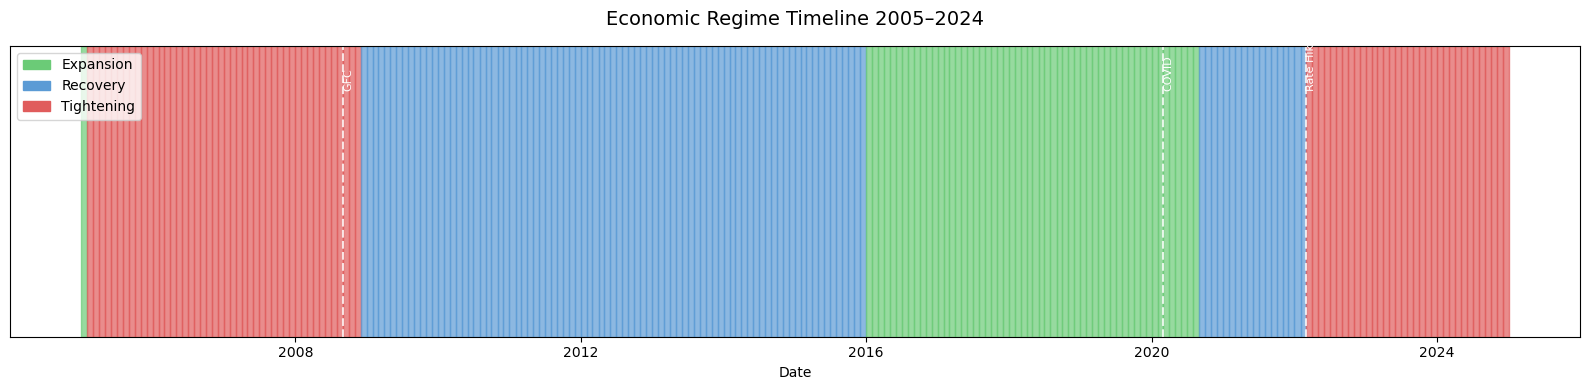

Plot saved


In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Color map for regimes
color_map = {
    'Expansion' : '#6bcb77',
    'Recovery'  : '#5b9bd5',
    'Tightening': '#e05c5c'
}

fig, ax = plt.subplots(figsize=(16, 4))

# Plot each month as a colored vertical bar
for date, row in regimes_df.iterrows():
    ax.axvspan(date, date + pd.DateOffset(months=1),
               color=color_map[row['Regime_Name']], alpha=0.7)

# Add legend
patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
ax.legend(handles=patches, loc='upper left', fontsize=10)

# Add key historical events as vertical lines
events = {
    '2008-09-01': 'GFC',
    '2020-03-01': 'COVID',
    '2022-03-01': 'Rate Hikes'
}

for date, label in events.items():
    ax.axvline(pd.Timestamp(date), color='white', linewidth=1.5, linestyle='--', alpha=0.8)
    ax.text(pd.Timestamp(date), 0.85, label, color='white',
            fontsize=8, rotation=90, transform=ax.get_xaxis_transform())

ax.set_title('Economic Regime Timeline 2005–2024', fontsize=14, pad=15)
ax.set_xlabel('Date')
ax.set_yticks([])
plt.tight_layout()
plt.savefig('regime_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved")

In [23]:
# Combine asset returns and regime labels into one dataframe
analysis_df = asset_returns.copy()
analysis_df['Regime'] = regimes_df['Regime_Name']

# Drop any rows where regime is missing
analysis_df = analysis_df.dropna()

print("Shape:", analysis_df.shape)
print("\nSample:")
print(analysis_df.head(10))

Shape: (240, 5)

Sample:
Ticker           GLD       QQQ       SPY       TLT      Regime
Date                                                          
2005-01-01 -0.036073 -0.054153 -0.017803  0.043891   Expansion
2005-02-01  0.031028 -0.004813  0.020904 -0.018428  Tightening
2005-03-01 -0.016311 -0.017464 -0.022134 -0.003917  Tightening
2005-04-01  0.012377 -0.043478 -0.014881  0.038067  Tightening
2005-05-01 -0.039216  0.088622  0.032224  0.031504  Tightening
2005-06-01  0.042977 -0.034139 -0.002511  0.021541  Tightening
2005-07-01 -0.014273  0.077124  0.042452 -0.033575  Tightening
2005-08-01  0.013545 -0.015159 -0.009374  0.034483  Tightening
2005-09-01  0.076037  0.012314  0.003753 -0.035912  Tightening
2005-10-01 -0.006424 -0.014952 -0.019495 -0.022847  Tightening


In [24]:
# Mean monthly return per asset per regime
regime_returns = analysis_df.groupby('Regime')[['GLD','QQQ','SPY','TLT']].mean()

# Annualize the returns (multiply monthly by 12)
regime_returns_annual = regime_returns * 12

print("Annualized mean returns by regime (%):")
print((regime_returns_annual * 100).round(2))

Annualized mean returns by regime (%):
Ticker        GLD    QQQ    SPY    TLT
Regime                                
Expansion   12.82  21.79  14.13  10.27
Recovery     3.89  19.94  15.23   3.80
Tightening  15.74   4.78   3.27  -0.02


In [25]:
# Monthly volatility annualized (multiply by sqrt of 12)
regime_vol = analysis_df.groupby('Regime')[['GLD','QQQ','SPY','TLT']].std() * (12 ** 0.5)

print("Annualized volatility by regime (%):")
print((regime_vol * 100).round(2))

Annualized volatility by regime (%):
Ticker        GLD    QQQ    SPY    TLT
Regime                                
Expansion   13.75  17.36  15.00  12.37
Recovery    17.88  16.45  14.74  14.52
Tightening  17.03  21.12  15.83  14.28


In [26]:
# Sharpe Ratio = Annualized Return / Annualized Volatility
# Assuming risk free rate of ~2% annually
risk_free = 0.02

sharpe = (regime_returns_annual - risk_free) / regime_vol

print("Sharpe Ratio by regime:")
print(sharpe.round(3))

Sharpe Ratio by regime:
Ticker        GLD    QQQ    SPY    TLT
Regime                                
Expansion   0.787  1.140  0.809  0.668
Recovery    0.106  1.090  0.898  0.124
Tightening  0.807  0.132  0.080 -0.141


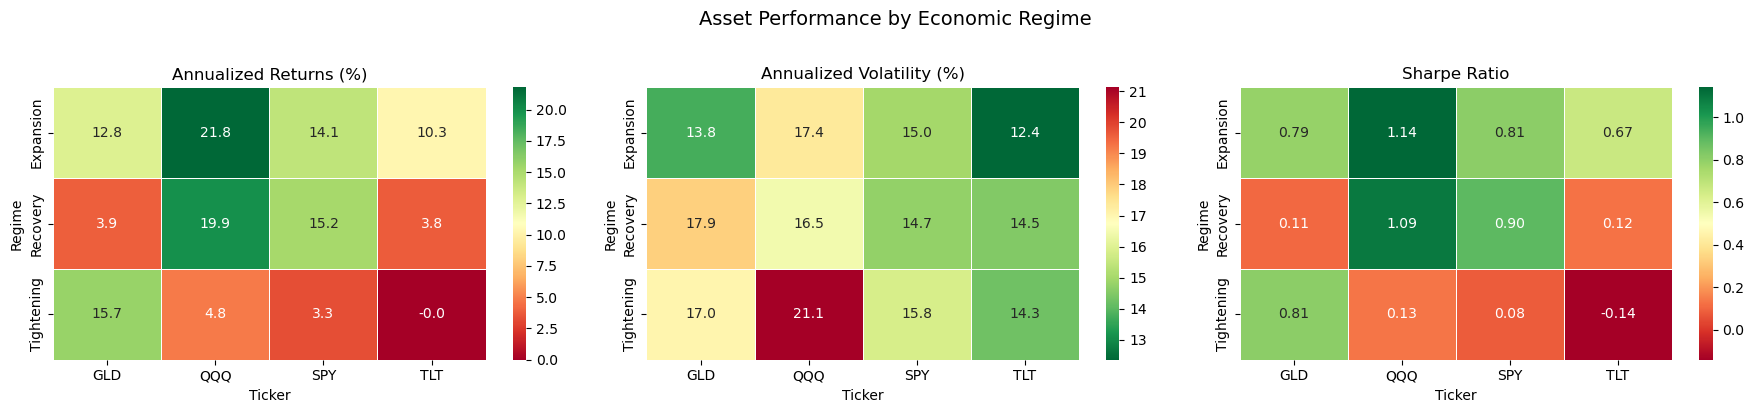

Plot saved


In [27]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Annualized Returns heatmap
sns.heatmap(regime_returns_annual * 100,
            annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Annualized Returns (%)', fontsize=12)

# 2. Volatility heatmap
sns.heatmap(regime_vol * 100,
            annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=axes[1])
axes[1].set_title('Annualized Volatility (%)', fontsize=12)

# 3. Sharpe Ratio heatmap
sns.heatmap(sharpe,
            annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[2])
axes[2].set_title('Sharpe Ratio', fontsize=12)

plt.suptitle('Asset Performance by Economic Regime', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('asset_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved")

In [28]:
# Define regime-based allocation weights
# Order: GLD, QQQ, SPY, TLT
allocations = {
    'Expansion' : {'GLD': 0.10, 'QQQ': 0.50, 'SPY': 0.30, 'TLT': 0.10},
    'Recovery'  : {'GLD': 0.10, 'QQQ': 0.45, 'SPY': 0.35, 'TLT': 0.10},
    'Tightening': {'GLD': 0.50, 'QQQ': 0.20, 'SPY': 0.20, 'TLT': 0.10}
}

# Verify all weights sum to 1
for regime, weights in allocations.items():
    total = sum(weights.values())
    print(f"{regime}: weights sum = {total}")

Expansion: weights sum = 1.0
Recovery: weights sum = 1.0
Tightening: weights sum = 1.0


In [29]:
# Transaction cost per rebalance (0.1% per trade)
transaction_cost = 0.001

# Starting portfolio value
portfolio_value = 100.0

# Track portfolio value and regime each month
portfolio = []
prev_regime = None

for date, row in analysis_df.iterrows():
    regime = row['Regime']
    weights = allocations[regime]

    # Calculate weighted return for this month
    monthly_return = (
        weights['GLD'] * row['GLD'] +
        weights['QQQ'] * row['QQQ'] +
        weights['SPY'] * row['SPY'] +
        weights['TLT'] * row['TLT']
    )

    # Apply transaction cost if regime changed
    if prev_regime is not None and regime != prev_regime:
        monthly_return -= transaction_cost

    # Update portfolio value
    portfolio_value = portfolio_value * (1 + monthly_return)
    prev_regime = regime

    portfolio.append({
        'Date'          : date,
        'Portfolio'     : portfolio_value,
        'Regime'        : regime,
        'Monthly_Return': monthly_return
    })

portfolio_df = pd.DataFrame(portfolio).set_index('Date')

print("Backtest complete")
print(f"Start value : $100.00")
print(f"End value   : ${portfolio_df['Portfolio'].iloc[-1]:.2f}")
print(f"Total return: {(portfolio_df['Portfolio'].iloc[-1] - 100):.1f}%")

Backtest complete
Start value : $100.00
End value   : $1322.44
Total return: 1222.4%


In [30]:
# Benchmark 1: 100% SPY (buy and hold)
spy_value = 100.0
spy_portfolio = []

for date, row in analysis_df.iterrows():
    spy_value = spy_value * (1 + row['SPY'])
    spy_portfolio.append({'Date': date, 'SPY_Buyhold': spy_value})

spy_df = pd.DataFrame(spy_portfolio).set_index('Date')

# Benchmark 2: 60/40 portfolio (60% SPY, 40% TLT)
balanced_value = 100.0
balanced_portfolio = []

for date, row in analysis_df.iterrows():
    monthly_return = 0.60 * row['SPY'] + 0.40 * row['TLT']
    balanced_value = balanced_value * (1 + monthly_return)
    balanced_portfolio.append({'Date': date, 'Balanced_6040': balanced_value})

balanced_df = pd.DataFrame(balanced_portfolio).set_index('Date')

# Combine everything
comparison_df = portfolio_df[['Portfolio']].copy()
comparison_df['SPY_Buyhold']   = spy_df['SPY_Buyhold']
comparison_df['Balanced_6040'] = balanced_df['Balanced_6040']

print("Final values:")
print(f"Regime Strategy : ${comparison_df['Portfolio'].iloc[-1]:.2f}")
print(f"SPY Buy & Hold  : ${comparison_df['SPY_Buyhold'].iloc[-1]:.2f}")
print(f"60/40 Portfolio : ${comparison_df['Balanced_6040'].iloc[-1]:.2f}")

Final values:
Regime Strategy : $1322.44
SPY Buy & Hold  : $707.46
60/40 Portfolio : $463.42


In [31]:
# Function to calculate performance metrics
def calculate_metrics(returns, name):
    # Annualized return
    n_years = len(returns) / 12
    total_return = (1 + returns).prod() - 1
    ann_return = (1 + total_return) ** (1 / n_years) - 1

    # Annualized volatility
    ann_vol = returns.std() * (12 ** 0.5)

    # Sharpe ratio (2% risk free)
    sharpe = (ann_return - 0.02) / ann_vol

    # Max drawdown
    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    drawdown = (cumulative - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    # Calmar ratio (annualized return / max drawdown)
    calmar = ann_return / abs(max_drawdown)

    print(f"\n{name}:")
    print(f"  Annualized Return : {ann_return*100:.2f}%")
    print(f"  Annualized Vol    : {ann_vol*100:.2f}%")
    print(f"  Sharpe Ratio      : {sharpe:.3f}")
    print(f"  Max Drawdown      : {max_drawdown*100:.2f}%")
    print(f"  Calmar Ratio      : {calmar:.3f}")

# Calculate for all three
calculate_metrics(portfolio_df['Monthly_Return'], 'Regime Strategy')

spy_returns = analysis_df['SPY']
calculate_metrics(spy_returns, 'SPY Buy & Hold')

balanced_returns = 0.60 * analysis_df['SPY'] + 0.40 * analysis_df['TLT']
calculate_metrics(balanced_returns, '60/40 Portfolio')


Regime Strategy:
  Annualized Return : 13.78%
  Annualized Vol    : 12.42%
  Sharpe Ratio      : 0.948
  Max Drawdown      : -25.12%
  Calmar Ratio      : 0.549

SPY Buy & Hold:
  Annualized Return : 10.28%
  Annualized Vol    : 15.19%
  Sharpe Ratio      : 0.545
  Max Drawdown      : -50.78%
  Calmar Ratio      : 0.202

60/40 Portfolio:
  Annualized Return : 7.97%
  Annualized Vol    : 10.22%
  Sharpe Ratio      : 0.584
  Max Drawdown      : -28.40%
  Calmar Ratio      : 0.281


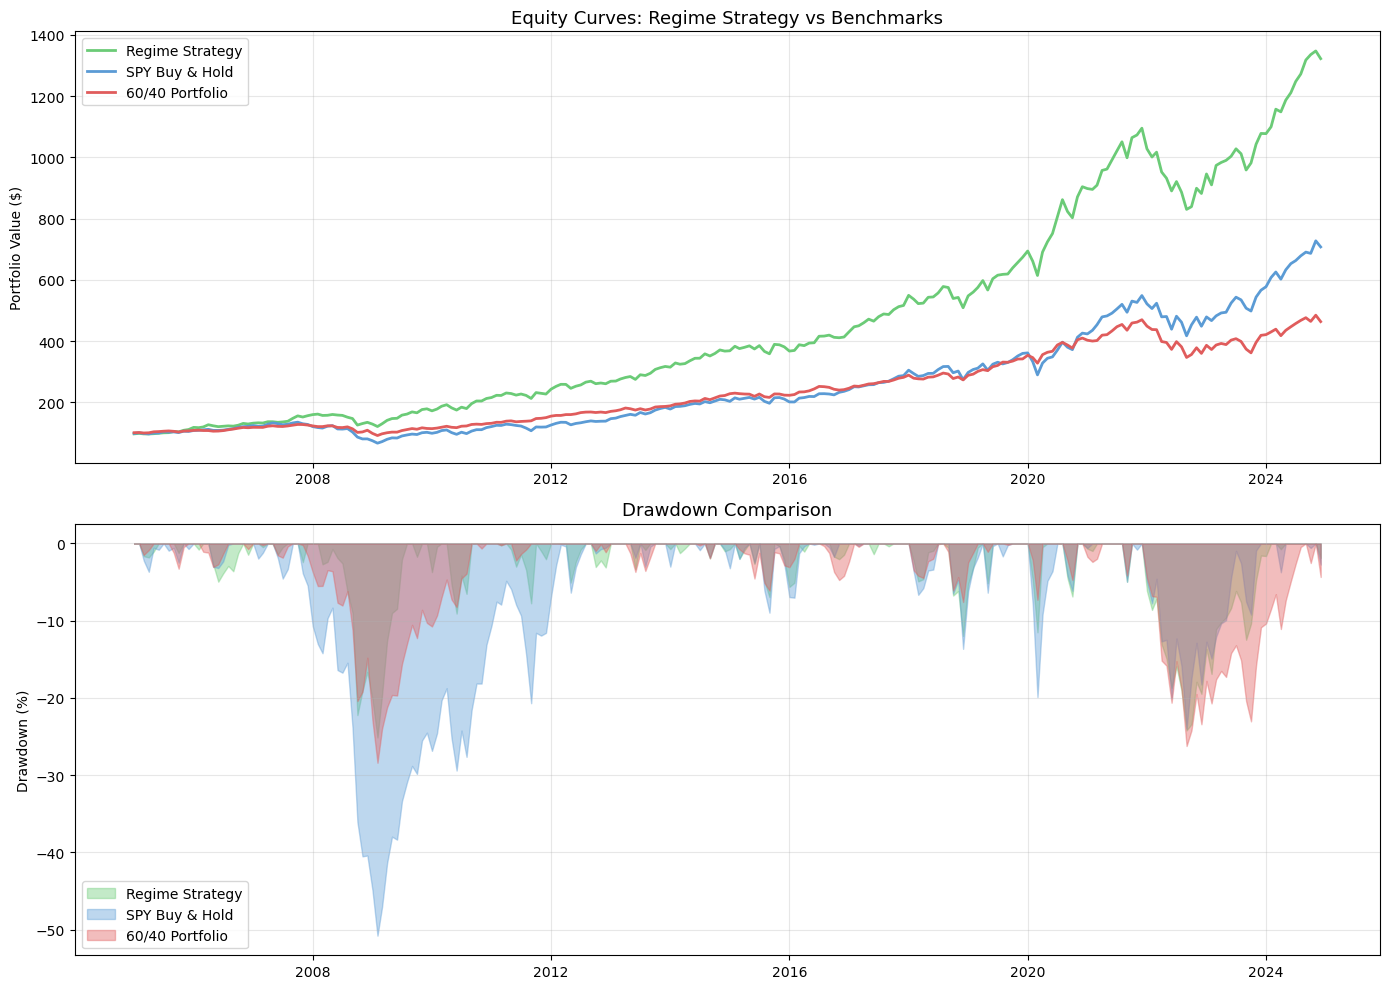

Plot saved


In [32]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Equity curves
axes[0].plot(comparison_df.index, comparison_df['Portfolio'],
             color='#6bcb77', linewidth=2, label='Regime Strategy')
axes[0].plot(comparison_df.index, comparison_df['SPY_Buyhold'],
             color='#5b9bd5', linewidth=2, label='SPY Buy & Hold')
axes[0].plot(comparison_df.index, comparison_df['Balanced_6040'],
             color='#e05c5c', linewidth=2, label='60/40 Portfolio')

axes[0].set_title('Equity Curves: Regime Strategy vs Benchmarks', fontsize=13)
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Drawdown chart
def get_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    rolling_max = cumulative.cummax()
    return (cumulative - rolling_max) / rolling_max

axes[1].fill_between(portfolio_df.index,
                     get_drawdown(portfolio_df['Monthly_Return']) * 100,
                     0, color='#6bcb77', alpha=0.4, label='Regime Strategy')
axes[1].fill_between(analysis_df.index,
                     get_drawdown(analysis_df['SPY']) * 100,
                     0, color='#5b9bd5', alpha=0.4, label='SPY Buy & Hold')
axes[1].fill_between(analysis_df.index,
                     get_drawdown(balanced_returns) * 100,
                     0, color='#e05c5c', alpha=0.4, label='60/40 Portfolio')

axes[1].set_title('Drawdown Comparison', fontsize=13)
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('backtest_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved")

In [33]:
# Train: 2005-2018 (in-sample)
# Test:  2019-2024 (out-of-sample) — includes COVID, inflation spike, rate hikes
# This is the hardest possible test period

train_end   = '2018-12-01'
test_start  = '2019-01-01'

# Split features
features_train = features_scaled[:train_end]
features_test  = features_scaled[test_start:]

# Split asset returns
returns_train  = analysis_df[:train_end]
returns_test   = analysis_df[test_start:]

print("Train period:", features_train.index[0].date(), "→", features_train.index[-1].date())
print("Test period :", features_test.index[0].date(), "→", features_test.index[-1].date())
print("\nTrain samples:", len(features_train))
print("Test samples :", len(features_test))

Train period: 2005-01-01 → 2018-12-01
Test period : 2019-01-01 → 2024-12-01

Train samples: 168
Test samples : 72


In [34]:
# Train a fresh HMM on training data only
# The model has never seen 2019-2024
oos_model = GaussianHMM(
    n_components=3,
    covariance_type='diag',
    n_iter=2000,
    random_state=33,
    init_params='r',
    params='stmc'
)

oos_model.fit(features_train)

# Predict regimes on training data
train_regimes = oos_model.predict(features_train)
train_counts  = pd.Series(train_regimes).value_counts()

print("Converged:", oos_model.monitor_.converged)
print("\nTrain regime counts:")
print(train_counts.sort_index())

Converged: True

Train regime counts:
0    37
1    49
2    82
Name: count, dtype: int64


In [35]:
# Predict regimes on test data (model has never seen this)
test_regimes = oos_model.predict(features_test)

# Map to regime names - need to figure out which state = which regime
# Check average conditions per state in training data
train_features_df = features[:train_end].copy()
train_features_df['State'] = train_regimes

state_profile = train_features_df.groupby('State')[['Fed_Funds_Rate', 
                                                      'Unemployment_Change',
                                                      'Yield_Spread',
                                                      'Consumer_Sentiment']].mean().round(3)
print("Training state profiles:")
print(state_profile)

Training state profiles:
       Fed_Funds_Rate  Unemployment_Change  Yield_Spread  Consumer_Sentiment
State                                                                       
0               0.499               -0.009         1.141              93.843
1               3.761               -0.002         0.288              89.716
2               0.346                0.002         2.081              72.401


In [36]:
# Map state numbers to regime names for OOS model
oos_regime_names = {
    0: 'Expansion',
    1: 'Tightening',
    2: 'Recovery'
}

# Create test regimes dataframe
test_regimes_df = pd.DataFrame({
    'Regime': [oos_regime_names[s] for s in test_regimes]
}, index=features_test.index)

print("OOS Regime counts:")
print(test_regimes_df['Regime'].value_counts())
print("\nSample:")
print(test_regimes_df.head(10))

OOS Regime counts:
Regime
Tightening    50
Recovery      21
Expansion      1
Name: count, dtype: int64

Sample:
                Regime
2019-01-01  Tightening
2019-02-01  Tightening
2019-03-01  Tightening
2019-04-01  Tightening
2019-05-01  Tightening
2019-06-01  Tightening
2019-07-01  Tightening
2019-08-01  Tightening
2019-09-01  Tightening
2019-10-01  Tightening


In [37]:
# Merge test returns with test regimes
test_df = returns_test.copy()
test_df['Regime'] = test_regimes_df['Regime']
test_df = test_df.dropna()

# Run OOS backtest
oos_portfolio_value = 100.0
oos_portfolio = []
prev_regime = None

for date, row in test_df.iterrows():
    regime = row['Regime']
    weights = allocations[regime]

    monthly_return = (
        weights['GLD'] * row['GLD'] +
        weights['QQQ'] * row['QQQ'] +
        weights['SPY'] * row['SPY'] +
        weights['TLT'] * row['TLT']
    )

    # Transaction cost on regime change
    if prev_regime is not None and regime != prev_regime:
        monthly_return -= transaction_cost

    oos_portfolio_value = oos_portfolio_value * (1 + monthly_return)
    prev_regime = regime

    oos_portfolio.append({
        'Date'          : date,
        'Portfolio'     : oos_portfolio_value,
        'Regime'        : regime,
        'Monthly_Return': monthly_return
    })

oos_df = pd.DataFrame(oos_portfolio).set_index('Date')

# SPY benchmark for same period
oos_spy_value = 100.0
oos_spy = []
for date, row in test_df.iterrows():
    oos_spy_value = oos_spy_value * (1 + row['SPY'])
    oos_spy.append({'Date': date, 'SPY': oos_spy_value})
oos_spy_df = pd.DataFrame(oos_spy).set_index('Date')

# 60/40 benchmark for same period
oos_balanced_value = 100.0
oos_balanced = []
for date, row in test_df.iterrows():
    ret = 0.60 * row['SPY'] + 0.40 * row['TLT']
    oos_balanced_value = oos_balanced_value * (1 + ret)
    oos_balanced.append({'Date': date, 'Balanced': oos_balanced_value})
oos_balanced_df = pd.DataFrame(oos_balanced).set_index('Date')

print("OOS Backtest Results (2019-2024):")
print(f"Regime Strategy : ${oos_df['Portfolio'].iloc[-1]:.2f}")
print(f"SPY Buy & Hold  : ${oos_spy_df['SPY'].iloc[-1]:.2f}")
print(f"60/40 Portfolio : ${oos_balanced_df['Balanced'].iloc[-1]:.2f}")

OOS Backtest Results (2019-2024):
Regime Strategy : $266.31
SPY Buy & Hold  : $258.37
60/40 Portfolio : $169.69


In [38]:
oos_returns = oos_df['Monthly_Return']
oos_spy_returns = test_df['SPY']
oos_balanced_returns = 0.60 * test_df['SPY'] + 0.40 * test_df['TLT']

calculate_metrics(oos_returns,          'OOS Regime Strategy')
calculate_metrics(oos_spy_returns,      'OOS SPY Buy & Hold')
calculate_metrics(oos_balanced_returns, 'OOS 60/40 Portfolio')


OOS Regime Strategy:
  Annualized Return : 17.73%
  Annualized Vol    : 13.42%
  Sharpe Ratio      : 1.172
  Max Drawdown      : -19.22%
  Calmar Ratio      : 0.923

OOS SPY Buy & Hold:
  Annualized Return : 17.14%
  Annualized Vol    : 17.70%
  Sharpe Ratio      : 0.855
  Max Drawdown      : -23.97%
  Calmar Ratio      : 0.715

OOS 60/40 Portfolio:
  Annualized Return : 9.21%
  Annualized Vol    : 13.63%
  Sharpe Ratio      : 0.529
  Max Drawdown      : -26.22%
  Calmar Ratio      : 0.351


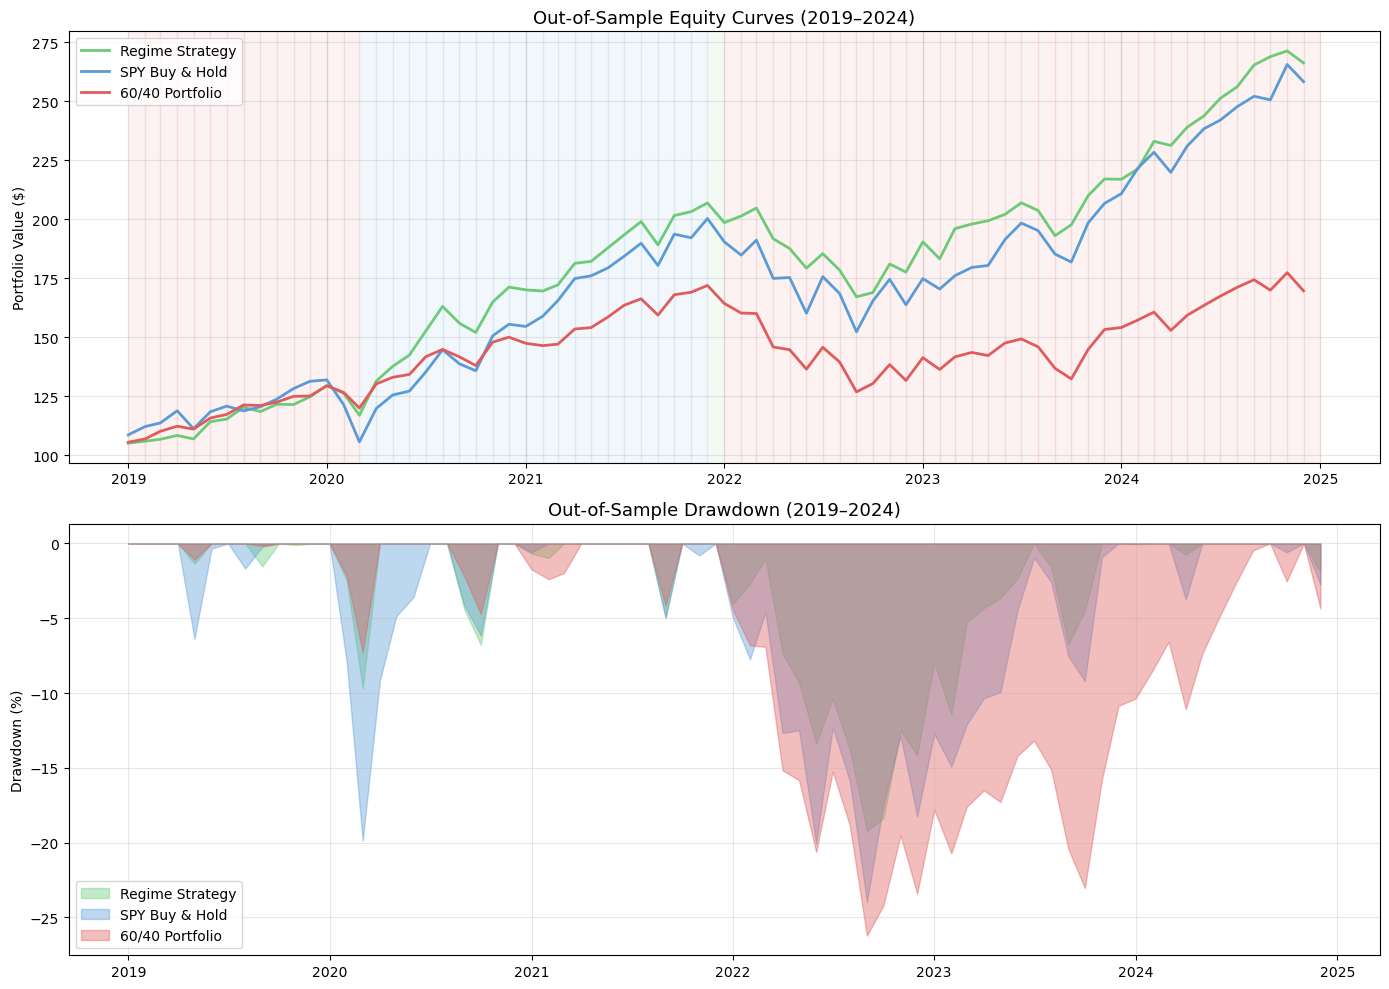

Plot saved


In [39]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: OOS Equity curves
axes[0].plot(oos_df.index, oos_df['Portfolio'],
             color='#6bcb77', linewidth=2, label='Regime Strategy')
axes[0].plot(oos_spy_df.index, oos_spy_df['SPY'],
             color='#5b9bd5', linewidth=2, label='SPY Buy & Hold')
axes[0].plot(oos_balanced_df.index, oos_balanced_df['Balanced'],
             color='#e05c5c', linewidth=2, label='60/40 Portfolio')

# Shade regimes on the equity curve
regime_colors = {
    'Expansion' : '#6bcb77',
    'Recovery'  : '#5b9bd5',
    'Tightening': '#e05c5c'
}

for date, row in test_regimes_df.iterrows():
    axes[0].axvspan(date, date + pd.DateOffset(months=1),
                    color=regime_colors[row['Regime']], alpha=0.08)

axes[0].set_title('Out-of-Sample Equity Curves (2019–2024)', fontsize=13)
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: OOS Drawdown
axes[1].fill_between(oos_df.index,
                     get_drawdown(oos_df['Monthly_Return']) * 100,
                     0, color='#6bcb77', alpha=0.4, label='Regime Strategy')
axes[1].fill_between(test_df.index,
                     get_drawdown(test_df['SPY']) * 100,
                     0, color='#5b9bd5', alpha=0.4, label='SPY Buy & Hold')
axes[1].fill_between(test_df.index,
                     get_drawdown(oos_balanced_returns) * 100,
                     0, color='#e05c5c', alpha=0.4, label='60/40 Portfolio')

axes[1].set_title('Out-of-Sample Drawdown (2019–2024)', fontsize=13)
axes[1].set_ylabel('Drawdown (%)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('oos_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved")